Device: cpu


100%|██████████| 170M/170M [37:38<00:00, 75.5kB/s]



 VGG
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 128MB/s]


vgg Epoch 1 Accuracy: 24.5 %
vgg Epoch 2 Accuracy: 53.5 %
vgg Epoch 3 Accuracy: 69.25 %

 RESNET
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s]


resnet Epoch 1 Accuracy: 19.0 %
resnet Epoch 2 Accuracy: 89.25 %
resnet Epoch 3 Accuracy: 96.25 %

 GOOGLENET
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 141MB/s]
/usr/local/lib/python3.13/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


googlenet Epoch 1 Accuracy: 20.75 %
googlenet Epoch 2 Accuracy: 67.75 %
googlenet Epoch 3 Accuracy: 83.0 %

Final Training Accuracy
VGG : 69.25 %
RESNET : 96.25 %
GOOGLENET : 83.0 %


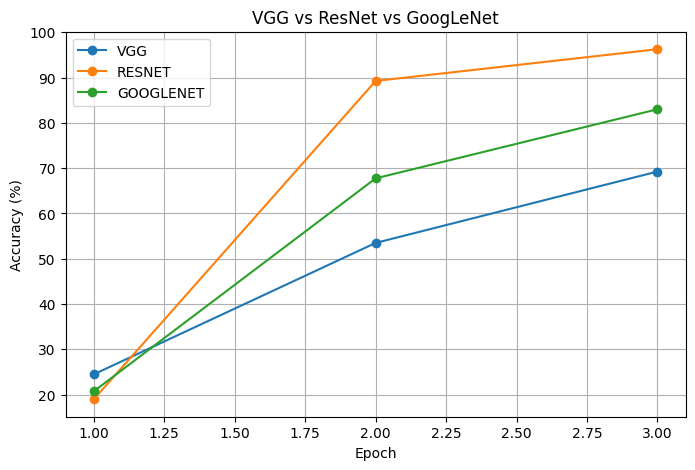

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import models, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3,(0.5,)*3)
])

data = torchvision.datasets.CIFAR10(
    './data', train=True, download=True, transform=transform
)

data = torch.utils.data.Subset(data, range(500))

train_size = 400
val_size = 100

train_data, val_data = random_split(data,[train_size,val_size])

train_loader = DataLoader(train_data,64,shuffle=True)
val_loader = DataLoader(val_data,64)

def get_model(name):
    if name == "vgg":
        m = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        m.classifier[6] = nn.Linear(4096,10)

    elif name == "resnet":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features,10)

    else:
        m = models.googlenet(
            weights=models.GoogLeNet_Weights.DEFAULT,
            aux_logits=True
        )
        m.fc = nn.Linear(m.fc.in_features,10)

    return m.to(device)

def train(model,name):
    loss_fn = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(),lr=0.0001)
    accs = []

    for e in range(3):
        model.train()
        correct = total = 0

        for x,y in train_loader:
            x,y = x.to(device),y.to(device)

            opt.zero_grad()
            out = model(x)

            if isinstance(out,tuple):
                out = out[0]

            loss = loss_fn(out,y)
            loss.backward()
            opt.step()

            correct += (out.argmax(1)==y).sum().item()
            total += len(y)

        acc = 100*correct/total
        accs.append(acc)

        print(name,"Epoch",e+1,"Accuracy:",round(acc,2),"%")

    return accs

results = {}

for name in ["vgg","resnet","googlenet"]:
    print("\n",name.upper())
    model = get_model(name)
    results[name] = train(model,name)

print("\nFinal Training Accuracy")
for name,acc in results.items():
    print(name.upper(),":",round(acc[-1],2),"%")

plt.figure(figsize=(8,5))

for name,acc in results.items():
    plt.plot(range(1,4),acc,marker='o',label=name.upper())

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("VGG vs ResNet vs GoogLeNet")
plt.legend()
plt.grid()
plt.show()